In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/rajut/OneDrive/Desktop/Medical_NoShow_Project/data.csv")


In [3]:
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous']
)

In [4]:
daily_df = df.groupby('appointment_date_continuous').size().reset_index()

In [5]:
daily_df.columns = ['date', 'appointments']

In [6]:
daily_df.set_index('date', inplace=True)

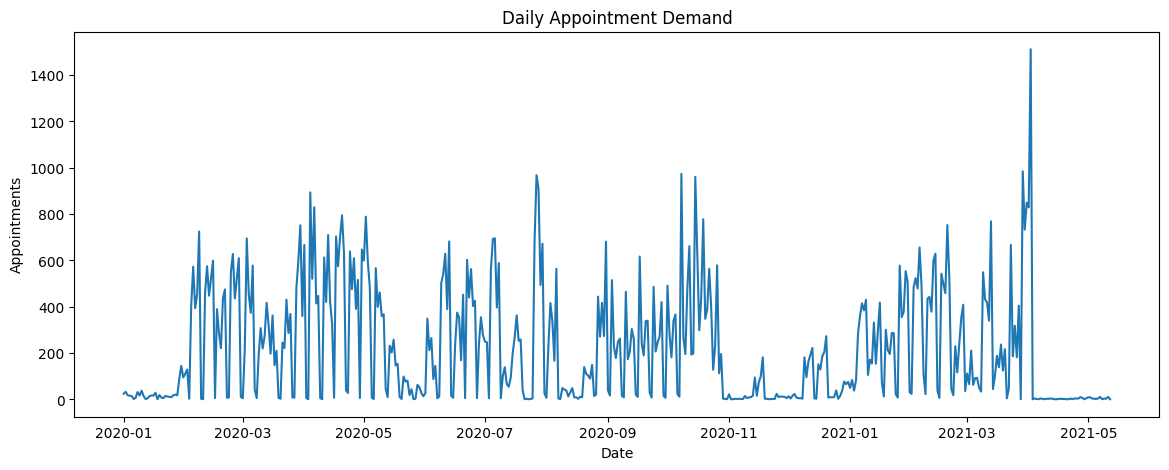

In [7]:
plt.figure(figsize=(14,5))

plt.plot(daily_df.index, daily_df['appointments'])

plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Appointments")

plt.show()

In [8]:
daily_df['day'] = daily_df.index.day

In [9]:
daily_df['month'] = daily_df.index.month

In [10]:
daily_df['weekday'] = daily_df.index.weekday

In [11]:
daily_df['is_weekend'] = daily_df['weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

In [12]:
daily_df['lag_1'] = daily_df['appointments'].shift(1)

In [13]:
daily_df['lag_7'] = daily_df['appointments'].shift(7)

In [14]:
daily_df['rolling_mean_7'] = (
    daily_df['appointments']
    .rolling(window=7)
    .mean()
)

In [15]:
daily_df.dropna(inplace=True)

In [16]:
X = daily_df.drop('appointments', axis=1)

In [17]:
y = daily_df['appointments']

In [18]:
split_index = int(len(daily_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

147.23138011383003


In [22]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print(rmse)

235.14321577885391


In [23]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)


0.3155845221911465


In [24]:
mape = np.mean(np.abs((y_test - y_pred)/y_test))*100

print(mape)

2969.120192616469


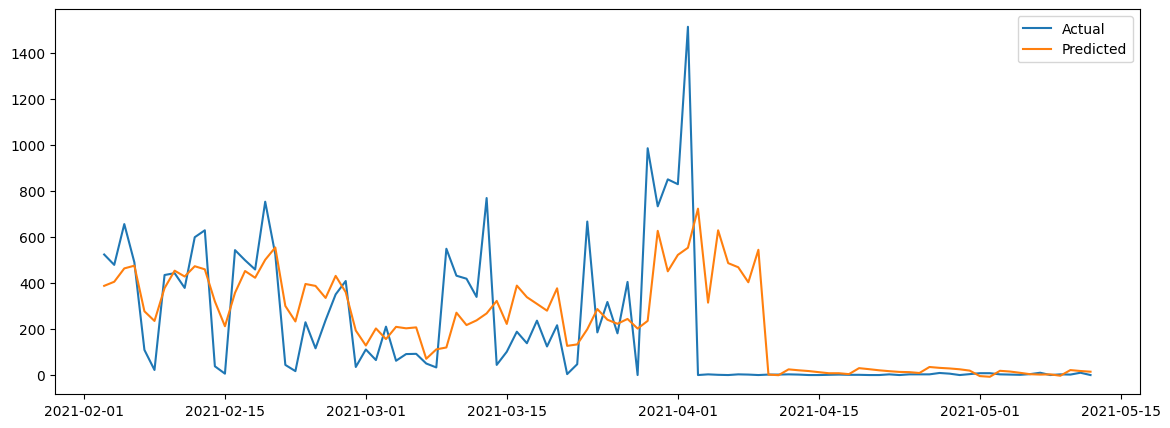

In [25]:
plt.figure(figsize=(14,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')

plt.legend()

plt.show()

In [26]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "first/forecast_model.pkl")

['first/forecast_model.pkl']

In [1]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print(model.feature_names_in_)

['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']


In [2]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print("Expected features:")
for col in model.feature_names_in_:
    print(col)

Expected features:
specialty
appointment_time
gender
disability
place
appointment_shift
age
under_12_years_old
over_60_years_old
patient_needs_companion
average_temp_day
average_rain_day
max_temp_day
max_rain_day
rainy_day_before
storm_day_before
rain_intensity
heat_intensity
appointment_date_continuous
Hipertension
Diabetes
Alcoholism
Handcap
Scholarship
SMS_received
day
month
weekday
is_weekend


In [3]:
print(len(model.feature_names_in_))

29


In [4]:
print(X_train.head())

NameError: name 'X_train' is not defined

In [5]:
print(X_train.dtypes)

NameError: name 'X_train' is not defined

In [6]:
import pandas as pd

df = pd.read_csv("data.csv")

# target column
y = df["no_show"]

# features
X = df.drop("no_show", axis=1)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print(X_train.dtypes)
print(X_train.iloc[0].to_dict())

specialty                       object
appointment_time                 int64
gender                          object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received                     int64
dtype: object
{'specialty

In [9]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print("Number of features:", len(model.feature_names_in_))
print(model.feature_names_in_)

Number of features: 29
['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']


In [11]:
df = pd.read_csv("data.csv")

print(df[model.feature_names_in_].head(1).to_dict("records")[0])

KeyError: "['day', 'month', 'weekday', 'is_weekend'] not in index"

In [12]:
df = pd.read_csv("data.csv")

print(df[model.feature_names_in_].head(1).to_dict("records")[0])


KeyError: "['day', 'month', 'weekday', 'is_weekend'] not in index"

In [13]:
print(df.columns.tolist())

['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received']


In [14]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print(len(model.feature_names_in_))
print(model.feature_names_in_)

29
['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']


In [15]:
import pandas as pd
import joblib

model = joblib.load("first/no_show_model.pkl")

sample = pd.DataFrame(columns=model.feature_names_in_)

print(sample.columns.tolist())

['specialty', 'appointment_time', 'gender', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'day', 'month', 'weekday', 'is_weekend']


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [17]:
pipeline.fit(X_train, y_train)

import joblib
joblib.dump(pipeline, "first/no_show_pipeline.pkl")

NameError: name 'pipeline' is not defined

In [18]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [19]:
import joblib

model = joblib.load("first/no_show_model.pkl")

print("Features expected by model:")
for col in model.feature_names_in_:
    print(col)

Features expected by model:
specialty
appointment_time
gender
disability
place
appointment_shift
age
under_12_years_old
over_60_years_old
patient_needs_companion
average_temp_day
average_rain_day
max_temp_day
max_rain_day
rainy_day_before
storm_day_before
rain_intensity
heat_intensity
appointment_date_continuous
Hipertension
Diabetes
Alcoholism
Handcap
Scholarship
SMS_received
day
month
weekday
is_weekend


In [1]:
import joblib

no_show_model = joblib.load("first/no_show_model.pkl")

print(type(no_show_model))

print("\nFeatures expected:")
print(no_show_model.feature_names_in_)

print("\nNumber of features:")
print(len(no_show_model.feature_names_in_))

<class 'sklearn.linear_model._logistic.LogisticRegression'>

Features expected:
['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']

Number of features:
29


In [2]:
forecast_model = joblib.load("first/forecast_model.pkl")

print(type(forecast_model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LogisticRegression(class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

import joblib
joblib.dump(pipeline, "first/no_show_pipeline.pkl")

NameError: name 'X_train' is not defined

In [5]:
pipeline.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [6]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.shape)
print(df.head())

(109593, 26)
        specialty  appointment_time gender no_show    disability  \
0   psychotherapy                17      F     yes  intellectual   
1             NaN                 7      M      no  intellectual   
2  speech therapy                16      M      no  intellectual   
3  speech therapy                14      M     yes  intellectual   
4   physiotherapy                 8      M      no         motor   

              place appointment_shift   age  under_12_years_old  \
0  Lake Marvinville         afternoon   9.0                   1   
1           ITAPEMA           morning  11.0                   1   
2            ITAJAÍ         afternoon   8.0                   1   
3         Sarahside         afternoon   9.0                   1   
4            ITAJAÍ           morning   NaN                   0   

   over_60_years_old  ...  storm_day_before  rain_intensity  heat_intensity  \
0                  0  ...                 1         no_rain            warm   
1                

In [7]:
X = df.drop("no_show", axis=1)

y = df["no_show"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print(X_train.shape)
print(y_train.shape)

(87674, 25)
(87674,)


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LogisticRegression(class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

ValueError: could not convert string to float: 'psychotherapy'

In [11]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'specialty',
    'disability',
    'place',
    'appointment_shift',
    'rain_intensity',
    'heat_intensity'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [12]:
X = df.drop("no_show", axis=1)
y = df["no_show"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

pipeline.fit(X_train, y_train)

ValueError: could not convert string to float: 'M'

In [15]:
print(df.select_dtypes(include='object').columns)

Index(['gender', 'no_show', 'appointment_date_continuous'], dtype='object')


In [16]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'specialty',
    'gender',
    'disability',
    'place',
    'appointment_shift',
    'rain_intensity',
    'heat_intensity'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [17]:
X = df.drop('no_show', axis=1)
y = df['no_show']

In [18]:
y = y.map({
    'No': 0,
    'Yes': 1
})

In [19]:
print(y.unique())

[nan]


In [20]:
print(df['no_show'].unique())

['yes' 'no']


In [21]:
df['no_show'] = df['no_show'].str.strip().str.lower()

y = df['no_show'].map({
    'no': 0,
    'yes': 1
})

print(y.unique())

[1 0]


In [22]:
print(df['no_show'].value_counts(dropna=False))

no_show
no     74761
yes    34832
Name: count, dtype: int64


In [23]:
print(df['no_show'].unique())

['yes' 'no']


In [24]:
df['no_show'] = df['no_show'].map({
    'no': 0,
    'yes': 1
})

In [25]:
print(df['no_show'].unique())

[1 0]


In [26]:
X = df.drop('no_show', axis=1)
y = df['no_show']

In [27]:
print(y.isna().sum())

0


In [28]:
X = df.drop('no_show', axis=1)
y = df['no_show']

In [29]:
print(X.isnull().sum())

specialty                          0
appointment_time                   0
gender                             0
disability                         0
place                              0
appointment_shift                  0
age                            22960
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2211
average_rain_day                2245
max_temp_day                    2227
max_rain_day                    2263
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print(X_train.select_dtypes(include='object').columns)

Index(['appointment_date_continuous'], dtype='object')


In [32]:
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous']
)

In [33]:
df['day'] = df['appointment_date_continuous'].dt.day
df['month'] = df['appointment_date_continuous'].dt.month
df['weekday'] = df['appointment_date_continuous'].dt.weekday

df['is_weekend'] = (
    df['weekday'] >= 5
).astype(int)

In [34]:
df['appointment_date_continuous'] = (
    df['appointment_date_continuous']
    .astype('int64') // 10**9
)

In [35]:
X = df.drop('no_show', axis=1)
y = df['no_show']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [38]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. 

In [39]:
import joblib

joblib.dump(pipeline, "first/no_show_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [40]:
y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69     14952
           1       0.39      0.48      0.43      6967

    accuracy                           0.60     21919
   macro avg       0.56      0.56      0.56     21919
weighted avg       0.62      0.60      0.61     21919



In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

probs = pipeline.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69     14952
           1       0.39      0.48      0.43      6967

    accuracy                           0.60     21919
   macro avg       0.56      0.56      0.56     21919
weighted avg       0.62      0.60      0.61     21919

[[9756 5196]
 [3642 3325]]
ROC-AUC: 0.590674681251667


In [42]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": pipeline.named_steps['model'].coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance.head(10))

                        Feature   Coefficient
10             average_temp_day  1.102226e-08
12                 max_temp_day  3.541424e-09
13                 max_rain_day  3.509386e-09
3                    disability  2.833355e-09
26                        month  6.580223e-10
5             appointment_shift  4.536765e-10
27                      weekday  3.808159e-10
18  appointment_date_continuous  3.658195e-10
28                   is_weekend  5.496841e-11
11             average_rain_day  4.785019e-11


In [43]:
daily = df.groupby(
    'appointment_date_continuous'
).size().reset_index(name='appointments')

In [44]:
daily['appointment_date_continuous'] = pd.to_datetime(
    daily['appointment_date_continuous']
)

daily = daily.sort_values(
    'appointment_date_continuous'
)

In [45]:
daily['day'] = daily['appointment_date_continuous'].dt.day
daily['month'] = daily['appointment_date_continuous'].dt.month
daily['weekday'] = daily['appointment_date_continuous'].dt.weekday

In [46]:
from sklearn.ensemble import RandomForestRegressor

X = daily[['day','month','weekday']]
y = daily['appointments']

split = int(len(daily)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

forecast_model = RandomForestRegressor()

forecast_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

pred = forecast_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 232.4431924623115
R2: -0.0031914990823100897


In [48]:
import joblib

joblib.dump(
    forecast_model,
    "first/forecast_model.pkl"
)

['first/forecast_model.pkl']

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

probs = pipeline.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Alcoholism
- Diabetes
- Handcap
- Hipertension
- SMS_received
- ...


In [50]:
import pandas as pd
import numpy as np
import joblib

In [51]:
df = pd.read_csv("data.csv")

In [52]:
daily = df.groupby(
    'appointment_date_continuous'
).size().reset_index(name='appointments')

daily.head()

,appointment_date_continuous,appointments
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [53]:
daily['appointment_date_continuous'] = pd.to_datetime(
    daily['appointment_date_continuous']
)

In [54]:
daily['day'] = daily['appointment_date_continuous'].dt.day
daily['month'] = daily['appointment_date_continuous'].dt.month
daily['weekday'] = daily['appointment_date_continuous'].dt.weekday

In [55]:
from sklearn.ensemble import RandomForestRegressor

X = daily[['day','month','weekday']]
y = daily['appointments']

In [56]:
from sklearn.ensemble import RandomForestRegressor

X = daily[['day','month','weekday']]
y = daily['appointments']

In [57]:
joblib.dump(forecast_model, "first/forecast_model.pkl")

['first/forecast_model.pkl']

In [58]:
import pandas as pd

df = pd.read_csv("data.csv")

daily = df.groupby(
    'appointment_date_continuous'
).size().reset_index(name='appointments')

daily.head()

,appointment_date_continuous,appointments
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [59]:
daily['appointment_date_continuous'] = pd.to_datetime(
    daily['appointment_date_continuous']
)

daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   appointment_date_continuous  498 non-null    datetime64[ns]
 1   appointments                 498 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 7.9 KB


In [60]:
daily['day'] = daily['appointment_date_continuous'].dt.day
daily['month'] = daily['appointment_date_continuous'].dt.month
daily['weekday'] = daily['appointment_date_continuous'].dt.weekday

daily.head()

,appointment_date_continuous,appointments,day,month,weekday
0,2020-01-01,25,1,1,2
1,2020-01-02,33,2,1,3
2,2020-01-03,18,3,1,4
3,2020-01-04,16,4,1,5
4,2020-01-05,15,5,1,6


In [61]:
X = daily[['day', 'month', 'weekday']]
y = daily['appointments']

print(X.head())
print(y.head())

   day  month  weekday
0    1      1        2
1    2      1        3
2    3      1        4
3    4      1        5
4    5      1        6
0    25
1    33
2    18
3    16
4    15
Name: appointments, dtype: int64


In [62]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(398, 3)
(100, 3)


In [63]:
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forecast_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [64]:
pred = forecast_model.predict(X_test)

print(pred[:10])

[285.96 405.71 417.13 478.45 513.65 175.22 188.87 312.59 352.9  450.04]


In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, pred))
print("MAPE:", mean_absolute_percentage_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 286.7165
MAPE: 75.15162017940986
R2: -0.5277296305262815


In [66]:
daily['lag_1'] = daily['appointments'].shift(1)
daily['lag_7'] = daily['appointments'].shift(7)

daily = daily.dropna()

In [67]:
X = daily[
    ['day', 'month', 'weekday', 'lag_1', 'lag_7']
]

y = daily['appointments']

In [68]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [69]:
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forecast_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [70]:
pred = forecast_model.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, pred))
print("MAPE:", mean_absolute_percentage_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 181.2329797979798
MAPE: 44.221711586771
R2: 0.13703979111622355


In [71]:
print(daily.shape)

(491, 7)


In [72]:
daily['lag_1'] = daily['appointments'].shift(1)
daily['lag_7'] = daily['appointments'].shift(7)

daily = daily.dropna()

print(daily.shape)

(484, 7)


In [73]:
X = daily[['day', 'month', 'weekday', 'lag_1', 'lag_7']]
y = daily['appointments']

In [74]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [75]:
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forecast_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [76]:
pred = forecast_model.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, pred))
print("MAPE:", mean_absolute_percentage_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 189.05159793814434
MAPE: 47.90619236004781
R2: 0.0883447618907861


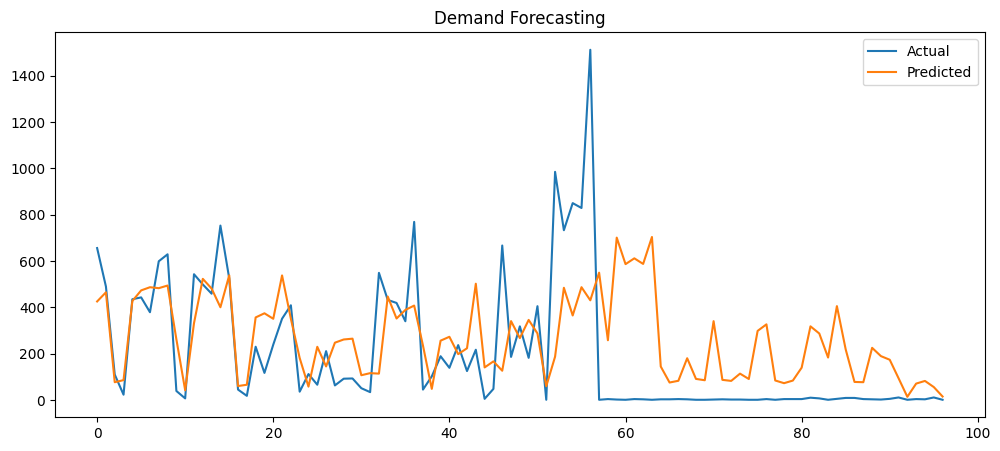

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Demand Forecasting")
plt.show()

In [78]:
import joblib

joblib.dump(forecast_model, "first/forecast_model.pkl")

['first/forecast_model.pkl']

In [79]:
daily = df.groupby('appointment_date_continuous').agg({
    'average_temp_day':'mean',
    'average_rain_day':'mean',
    'Hipertension':'sum',
    'Diabetes':'sum',
    'SMS_received':'sum',
    'no_show':'count'
}).reset_index()


In [80]:
joblib.dump(forecast_model, "first/forecast_model.pkl")

['first/forecast_model.pkl']

In [81]:
forecast_model = joblib.load(
    "first/forecast_model.pkl"
)

In [82]:
import joblib

pipeline = joblib.load("first/no_show_pipeline.pkl")
print(pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


In [83]:
print(pipeline.feature_names_in_)

['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']


In [84]:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. 

In [85]:
print(pipeline.feature_names_in_)

['specialty' 'appointment_time' 'gender' 'disability' 'place'
 'appointment_shift' 'age' 'under_12_years_old' 'over_60_years_old'
 'patient_needs_companion' 'average_temp_day' 'average_rain_day'
 'max_temp_day' 'max_rain_day' 'rainy_day_before' 'storm_day_before'
 'rain_intensity' 'heat_intensity' 'appointment_date_continuous'
 'Hipertension' 'Diabetes' 'Alcoholism' 'Handcap' 'Scholarship'
 'SMS_received' 'day' 'month' 'weekday' 'is_weekend']


In [86]:
print(df[['specialty']].drop_duplicates().head(20))
print(df[['gender']].drop_duplicates())
print(df[['place']].drop_duplicates().head(20))
print(df[['appointment_shift']].drop_duplicates())
print(df[['rain_intensity']].drop_duplicates())
print(df[['heat_intensity']].drop_duplicates())

                specialty
0           psychotherapy
1                     NaN
2          speech therapy
4           physiotherapy
9    occupational therapy
17                 assist
29               pedagogo
90                    enf
442     sem especialidade
   gender
0       F
1       M
31      I
                 place
0     Lake Marvinville
1              ITAPEMA
2               ITAJAÍ
3            Sarahside
8           Stokesfort
10        Deborahmouth
11                 NaN
12               PENHA
13           Moranside
15         North Aaron
16          NAVEGANTES
17        Mendozahaven
18  North Diamondburgh
19      New Sherrifurt
20           Mooretown
21         B. CAMBORIU
23       Elizabethfurt
24       Port Johnstad
27          Nicoleberg
28          Greenestad
  appointment_shift
0         afternoon
1           morning
   rain_intensity
0         no_rain
3        moderate
18           weak
23          heavy
   heat_intensity
0            warm
1            cold
3            

In [87]:
print(df.dtypes)
print(df.head())

specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received             

In [88]:
input_data = pd.DataFrame({
    'specialty': [0],
    'appointment_time': [10],
    'gender': [1 if gender=="M" else 0],
    'disability': [0],
    'place': [0],
    'appointment_shift': [0],
    'age': [age],
    'under_12_years_old': [1 if age < 12 else 0],
    'over_60_years_old': [1 if age > 60 else 0],
    'patient_needs_companion': [0],
    'average_temp_day': [30],
    'average_rain_day': [5],
    'max_temp_day': [35],
    'max_rain_day': [10],
    'rainy_day_before': [0],
    'storm_day_before': [0],
    'rain_intensity': [0],
    'heat_intensity': [0],
    'appointment_date_continuous': [100],
    'Hipertension': [hypertension],
    'Diabetes': [diabetes],
    'Alcoholism': [0],
    'Handcap': [0],
    'Scholarship': [0],
    'SMS_received': [1],
    'day': [15],
    'month': [6],
    'weekday': [0],
    'is_weekend': [0]
})

NameError: name 'gender' is not defined